In [18]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Notebook illustrates
- loading mseed data
- remove geophone response
- plot seismogram
- compute spectrogram
- plot spectrogram

@ daniel binder
Golm, 09.06.2026
"""

import numpy as np
import pandas as pd
import scipy.signal

from obspy.signal.invsim import corn_freq_2_paz
from obspy import read, read_inventory, Stream
from obspy import UTCDateTime

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set plot parameters
plt.rcParams.update({
    'font.size': 14,        
    'axes.titlesize': 28,   
    'axes.labelsize': 28,   
    'xtick.labelsize': 20,  
    'ytick.labelsize': 20,  
    'legend.fontsize': 20  
})

# --- FUNCTIONS ---
def preproc(st, stid, fmin):
    st = st.copy()
    # detrend
    st. detrend('constant')

    # apply a bandpass filter
    #st.filter('bandpass', freqmin = 0.05, freqmax = 25)

    # remove impulse response function from data
    '''
    # define impulse response parameters for the GS ONE LF (4.5Hz) geophone, 71% damping
    # parameters from 
    # http://ds.iris.edu/NRL/sensors/oyo_geospace/RESP.XX.NS487..SHZ.GSONELF.2450.20000.4_5.89_44
    gsone = {   
                'gain':         1,
                'poles':[       (-2.007840e+01 + 1.916930e+01j),
                                (-2.007840e+01 - 1.916930e+01j)  ],
                'sensitivity':  1,
                'zeros':        [0j, 0j]
            }
    '''

    # calculate instrument response for GS ONE LF 4.5Hz, 71% damping 
    inst4_5hz = corn_freq_2_paz(4.5, damp = 0.707)
    instfmin = corn_freq_2_paz(fmin, damp = 0.707)

    # remove instrument response
    st.simulate( paz_remove = inst4_5hz, paz_simulate = instfmin, water_level = 0 )

    # single traces: edit network and convert to ground motion in m/s
    for tr in st:
        tr.stats.network = 'DK'
        tr.stats.station = stid[str(tr.stats.station)]
        
        if tr.stats.station == 'ZACR':
            if tr.stats.channel == '001':
                tr.stats.channel = 'DPZ'
            if tr.stats.channel == '002':
                tr.stats.channel = 'DPN'
            if tr.stats.channel == '003':
                tr.stats.channel = 'DPE'
                
        elif tr.stats.station == 'ZACP':
            if tr.stats.channel == '001':
                tr.stats.channel = 'DPZ'
            if tr.stats.channel == '002':
                tr.stats.channel = 'DPN'
            if tr.stats.channel == '003':
                tr.stats.channel = 'DPE'

        # convert counts to ground velocity in m/s
        bitweight = 2.98023e-07
        gain = 32
        sensitivity = 89.44
        tr.data = tr.data * bitweight / (gain * sensitivity)

    return st

# ---

# --- PARAMETERS ---
base_dir = Path("/media/db/DB_2TBext4/up_env_seismology")
data_dir = base_dir / '01_data/now'

# List of target Day of Year folders and stations
doy_start = 214
doy_end = 221
doy_folders = [str(doy) for doy in range(doy_start, doy_end+1)]

# Define dictionary with NOW station ids and names
stid = {'0000H':'ZACR', '0000G':'ZACP'}

# Define new sampling rate
new_sps = 200.0

# Define the scaling factor for the STEIM2 conversion
sc = 1e9

In [19]:
# Initialize separate master streams
st_G = Stream()
st_H = Stream()

print(f"Scanning DOY folders ({doy_start}-{doy_end}) for stations 0000G and 0000H...")

# Loop through each Day of Year folder
for doy in doy_folders:
    cur_doy_dir = data_dir / doy
    print(f"\nProcessing Day of Year: {doy}")
    
    # Check both station folders inside this specific DOY directory
    for station in stid.keys():
        station_dir = cur_doy_dir / station
        
        if not station_dir.exists():
            print(f" -> Subfolder missing, skipping: {station_dir.name}")
            continue
            
        # Find all hourly mseed files inside this specific station folder
        mseed_files = sorted(list(station_dir.glob("*.msd")))
        print(f" -> Found {len(mseed_files)} hourly files for station {station}")
        
        # 3. Read and downsample each hour file
        for file_path in mseed_files:
            try:
                st_hour = read(str(file_path))
                
                for tr in st_hour:
                    # Apply conditioning/downsampling if needed
                    if tr.stats.sampling_rate != new_sps:
                        tr.detrend('linear')
                        tr.taper(max_percentage=0.05, type='hann')
                        
                        decimation_factor = tr.stats.sampling_rate / new_sps
                        
                        if decimation_factor.is_integer() and decimation_factor > 1:
                            tr.decimate(int(decimation_factor), no_filter=False)
                        else:
                            tr.interpolate(sampling_rate=new_sps, method='weighted_average_slopes')
                                    
                    # Convert to float32 to minimize memory usage
                    tr.data = tr.data.astype(np.float32)
                    tr.stats.mseed.encoding = "FLOAT32"
                    
                    # Append trace to its designated master stream
                    if station == '0000G':
                        st_G.append(tr)
                    elif station == '0000H':
                        st_H.append(tr)
                        
            except Exception as e:
                print(f"    Error reading file {file_path.name}: {e}")
                continue

# 4. Merge all collected hourly segments cleanly
print("\nStitching hourly data blocks together...")
st_G.merge(method=1, fill_value='interpolate')
st_H.merge(method=1, fill_value='interpolate')

print("\n--- Data Streams Loaded Successfully ---")
print("Stream 0000G Structure:\n", st_G)
print("Stream 0000H Structure:\n", st_H)

Scanning DOY folders (214-221) for stations 0000G and 0000H...

Processing Day of Year: 214
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G

Processing Day of Year: 215
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G

Processing Day of Year: 216
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G

Processing Day of Year: 217
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G

Processing Day of Year: 218
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G

Processing Day of Year: 219
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G

Processing Day of Year: 220
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G

Processing Day of Year: 221
 -> Found 72 hourly files for station 0000H
 -> Found 72 hourly files for station 0000G



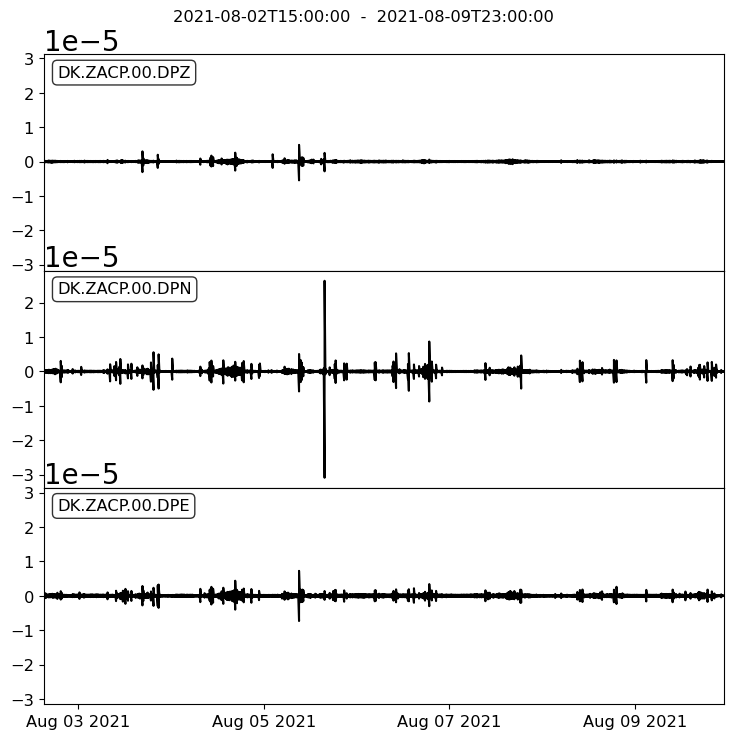

Stream saved to /media/db/DB_2TBext4/up_env_seismology/01_data/now/ZACP_doy214_221_200sps_corrected_scaled_1e9.mseed.


In [20]:
# ZACP
# Remove known geophone response
# Convert from counts to velocity
st_G_proc = preproc(st_G, stid, 0.5)

# Plot seismogram
# Define your start and end datetime
start = UTCDateTime("2021-08-02T15:00:00")
end = UTCDateTime("2021-08-09T23:00:00")

fig = st_G_proc.plot(
    starttime=start,
    endtime=end,
    handle=False,  
    color='black', 
    linewidth=0.5
)

# Scale stream for STEIM compression
for tr in st_G_proc:
    # Scale by 10^9 converts velocity from m/s to nm/s so decimals are not rounded to 0
    tr.data = (tr.data * sc).astype(np.int32)
            
    # Explicitly reset the metadata container to handle STEIM2 compression
    tr.stats.mseed = {'encoding': 'STEIM2'} 
        
# Save processed data stream
st_G_proc.write(
    data_dir / f'{stid['0000G']}_doy{doy_start}_{doy_end}_{int(new_sps)}sps_corrected_scaled_1e9.mseed', 
    format="MSEED",
    encoding='STEIM2'
)

print(f"Stream saved to {data_dir / stid['0000G']}_doy{doy_start}_{doy_end}_{int(new_sps)}sps_corrected_scaled_1e9.mseed.")

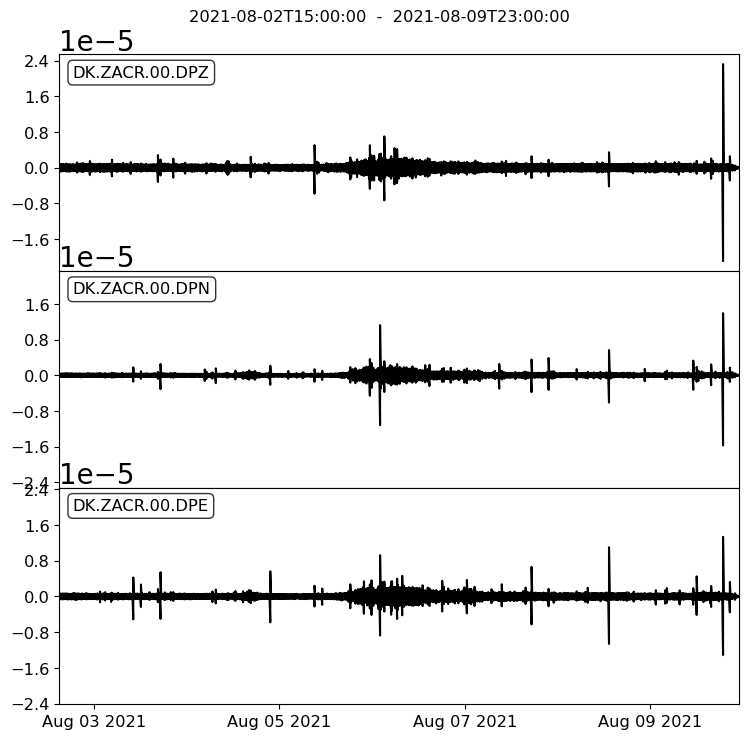

Stream saved to /media/db/DB_2TBext4/up_env_seismology/01_data/now/ZACR_doy214_221_200sps_corrected_scaled_1e9.mseed.


In [21]:
# ZACR
# Remove known geophone response
# Convert from counts to velocity
st_H_proc = preproc(st_H, stid, 0.5)

# Define your start and end datetime
start = UTCDateTime("2021-08-02T15:00:00")
end = UTCDateTime("2021-08-09T23:00:00")

# Plot seismogram
fig = st_H_proc.plot(
    starttime=start,
    endtime=end,
    handle=False,  
    color='black', 
    linewidth=0.5
)

# Scale stream for STEIM compression
for tr in st_H_proc:
    # Scale by 10^9 converts velocity from m/s to nm/s so decimals are not rounded to 0
    tr.data = (tr.data * sc).astype(np.int32)
            
    # Explicitly reset the metadata container to handle STEIM2 compression
    tr.stats.mseed = {'encoding': 'STEIM2'} 
        
# Save processed data stream
st_H_proc.write(
    data_dir / f'{stid['0000H']}_doy{doy_start}_{doy_end}_{int(new_sps)}sps_corrected_scaled_1e9.mseed', 
    format="MSEED",
    encoding='STEIM2'
)

print(f"Stream saved to {data_dir / stid['0000H']}_doy{doy_start}_{doy_end}_{int(new_sps)}sps_corrected_scaled_1e9.mseed.")

In [24]:
# Load datastreams and rescale
st = read(data_dir / f'{stid['0000G']}_doy{doy_start}_{doy_end}_{int(new_sps)}sps_corrected_scaled_1e9.mseed')
#st = read(data_dir / f'{stid['0000H']}_doy{doy_start}_{doy_end}_{int(new_sps)}sps_corrected_scaled_1e9.mseed')

for tr in st:
    tr.data = tr.data / sc
    
# Before looping over the traces define Welch parameters
# Get sampling rate from stream
sps = st[0].stats.sampling_rate

# Primary time window size for the Welch function (e.g., 30 minutes = 1800 seconds)
window_duration_min = 30
window_duration_sec = window_duration_min * 60  
n = int(window_duration_sec * sps)  # Samples per primary window

# Internal Welch sub-segment settings
nperseg = int(n // 6)       # Length of internal sub-segments
noverlap = int(nperseg // 2) # Overlap between internal sub-segments (e.g., 50%)

# Initiate master lists
all_psds = []
all_times = []
all_channels = []

# Loop over traces inside your existing stream object
for tr in st:
    try:
        # Skip tiny gap segments that are shorter than 1 hour
        if len(tr.data) < n:
            continue
            
        # Extract start date parameters directly from the trace metadata
        day_start = pd.Timestamp(tr.stats.starttime.datetime)

        # Compute Welch matrices for this specific trace array
        # Continuous data is shaped into a 2D matrix: [num_windows, n]
        num_windows = len(tr.data) // n  
        signal_windows = np.array([tr.data[i * n: (i + 1) * n] for i in range(num_windows)])

        # axis=1 forces SciPy to calculate the PSD for each time window independently
        f, psd = scipy.signal.welch(
            signal_windows, 
            fs=sps, 
            nperseg=nperseg, 
            noverlap=noverlap, 
            scaling='density',
            axis=1
        )
        
       # Generate a timestamp for each window center point
        num_windows_processed = psd.shape[0]
        day_times = [
            day_start + pd.Timedelta(minutes=(i * window_duration_min) + (window_duration_min / 2)) 
            for i in range(num_windows_processed)
        ]

        # Create a channel string tag for each calculated hour block
        day_channels = [str(tr.stats.channel)] * num_hours
        
        # Append results to master lists
        all_psds.append(psd)
        all_times.extend(day_times)
        all_channels.extend(day_channels) 
        
        print(f"Computed PSD for {tr.stats.station} channel {tr.stats.channel} and the period {tr.stats.starttime} to {tr.stats.endtime}")
        
    except Exception as e:
        print(f"Skipping trace {tr.id} due to calculation error: {e}")
        continue
        
# Combine masters
master_psd = np.concatenate(all_psds, axis=0)  # Shape: (total_hours, frequency_bins)
master_times = np.array(all_times, dtype='datetime64[ns]')
master_channels = np.array(all_channels, dtype=str)

# Save masters
# Create storage path
proc_data_dir = base_dir / '02_processed_data/now'
proc_data_dir.mkdir(parents=True, exist_ok=True)

# Create filename
npz_fn = (
    str(st[0].stats.station)+
    '_'+
    str(st[0].stats.starttime.year)+
    str(st[0].stats.starttime.month).zfill(2)+
    str(st[0].stats.starttime.day).zfill(2) +
    '_'+ 
    str(st[-1].stats.endtime.month).zfill(2)+
    str(st[-1].stats.endtime.day).zfill(2)+
    '.npz'
)

save_path = proc_data_dir / npz_fn

# Save all components into a compressed file
np.savez_compressed(
    save_path, 
    psd=master_psd, 
    times=master_times, 
    frequencies=f,
    channels=master_channels
)

print(f"\nData successfully saved to: {save_path}")

Computed PSD for ZACP channel DPZ and the period 2021-08-02T00:00:00.000000Z to 2021-08-09T23:59:59.995000Z
Computed PSD for ZACP channel DPN and the period 2021-08-02T00:00:00.000000Z to 2021-08-09T23:59:59.995000Z
Computed PSD for ZACP channel DPE and the period 2021-08-02T00:00:00.000000Z to 2021-08-09T23:59:59.995000Z

Data successfully saved to: /media/db/DB_2TBext4/up_env_seismology/02_processed_data/now/ZACP_20210802_0809.npz


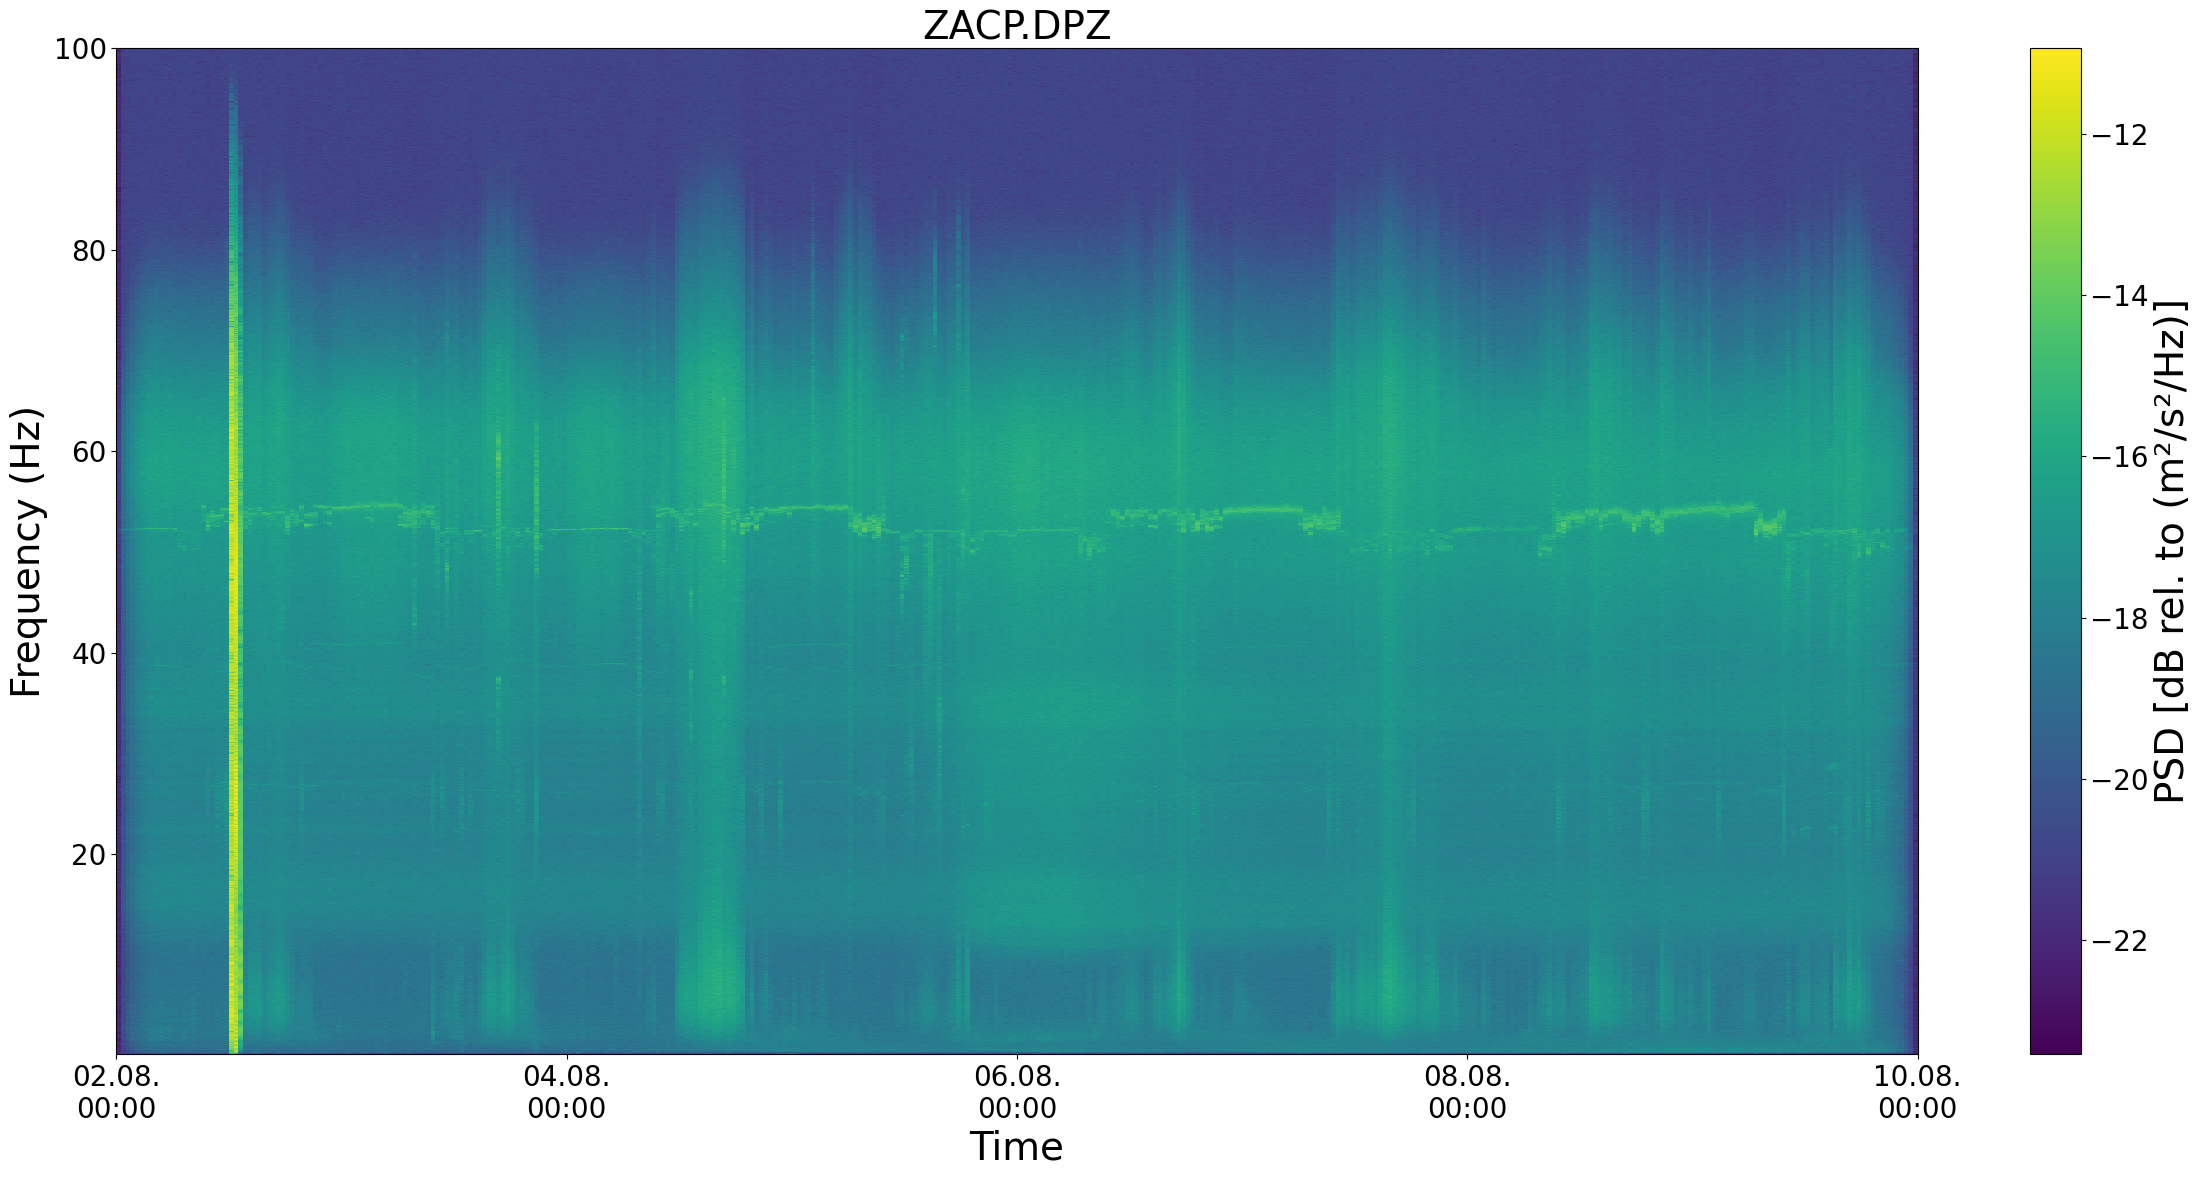

In [25]:
# define channel to plot the spectrogram
ch = 'DPZ'

# Create a boolean mask matching the channel for each hour row
ch_mask = (master_channels == ch)

# Slice the global matrices to isolate just this channel
plot_times = master_times[ch_mask]
plot_psd = master_psd[ch_mask, :]

# Plot spectrogram
fig, ax = plt.subplots(figsize=(24, 12))

# Plot time array against frequency matrix. Transpose (.T) is needed to match pcolormesh axis structure.
pcm = ax.pcolormesh(
    plot_times, 
    f, 
    np.log10(plot_psd.T),
    cmap='viridis', 
    shading='nearest'
)

# Format colorbar
cbar = fig.colorbar(
    pcm, 
    ax=ax, 
    label='PSD [dB rel. to (m²/s²/Hz)]'
)

# Format axes and dates
ax.set_ylim(0.1, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.\n%H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) 
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time")
ax.set_title(f"{st[0].stats.station}.{ch}")
plt.tight_layout()

# if not there create figures directory
figures_dir = base_dir / '03_figures/now'
figures_dir.mkdir(parents=True, exist_ok=True)

# replace extension for png figure
png_fn = npz_fn.replace('.npz', '.png')

plt.savefig(figures_dir / png_fn, dpi = 300)

plt.show()